In [1]:
from matplotlib import pyplot as plt
import sys
sys.path.append('..')
from csv_handling import load_csv

In [2]:
ages = list(range(21,39))

agefiles = {}
for age in ages:
    agefiles[age] = (
            load_csv(f'sta{age}_props_Table.csv',keycol='Segment'),
            load_csv(f'sta{age}_tissue_props.csv',keycol='Segment')
    )


In [3]:
regions = []
with open('labelnames.txt') as fp:
    for line in fp.readlines():
        parts = line.split('\t')
        regions.append(parts[1].replace('_',' '))

In [4]:
regions

['Clear Label',
 'Precentral L',
 'Precentral R',
 'Frontal Sup L',
 'Frontal Sup R',
 'Frontal Sup Orb L',
 'Frontal Sup Orb R',
 'Frontal Mid L',
 'Frontal Mid R',
 'Frontal Mid Orb L',
 'Frontal Mid Orb R',
 'Frontal Inf Oper L',
 'Frontal Inf Oper R',
 'Frontal Inf Tri L',
 'Frontal Inf Tri R',
 'Frontal Inf Orb L',
 'Frontal Inf Orb R',
 'Rolandic Oper L',
 'Rolandic Oper R',
 'Supp Motor Area L',
 'Supp Motor Area R',
 'Olfactory L',
 'Olfactory R',
 'Frontal Sup Medial L',
 'Frontal Sup Medial R',
 'Frontal Med Orb L',
 'Frontal Med Orb R',
 'Rectus L',
 'Rectus R',
 'Insula L',
 'Insula R',
 'Cingulum Ant L',
 'Cingulum Ant R',
 'Cingulum Mid L',
 'Cingulum Mid R',
 'Cingulum Post L',
 'Cingulum Post R',
 'Hippocampus L',
 'Hippocampus R',
 'ParaHippocampal L',
 'ParaHippocampal R',
 'Amygdala L',
 'Amygdala R',
 'Calcarine L',
 'Calcarine R',
 'Cuneus L',
 'Cuneus R',
 'Lingual L',
 'Lingual R',
 'Occipital Sup L',
 'Occipital Sup R',
 'Occipital Mid L',
 'Occipital Mid R',
 '

In [5]:
len(regions)

127

In [6]:
selected_region =  'Amygdala R' #'Internal Capsule R' 
# selected_region =  'CorpusCallosum' # 

In [9]:
agefiles[21][0][selected_region]._fields

('Segment',
 'Surface_area__mm2_',
 'Number_of_voxels__voxels_',
 'Volume__mm3_',
 'Volume__cm3_',
 'Minimum',
 'Maximum',
 'Mean',
 'Median',
 'Standard_Deviation')

In [10]:
colname = 'Volume__mm3_'

C:\Users\keerthi\AppData\Local\Temp\ipykernel_13840\2885182307.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


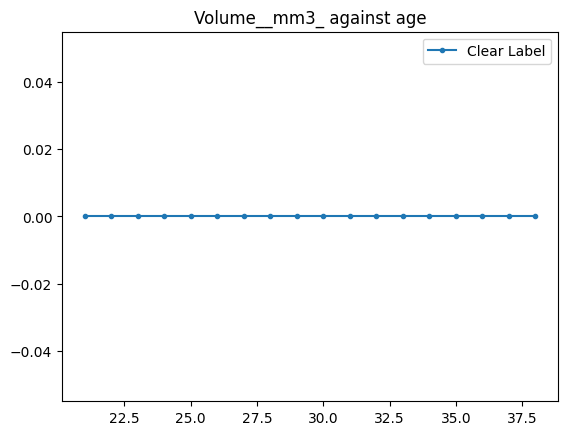

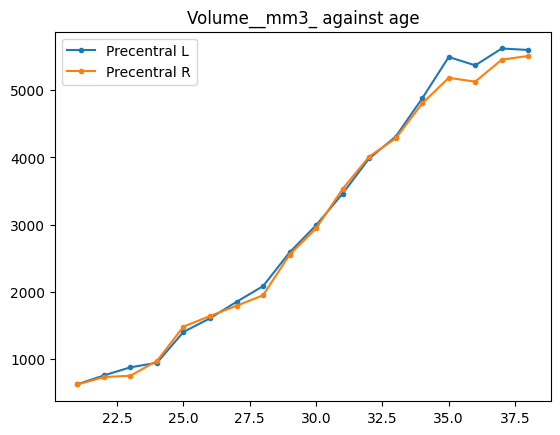

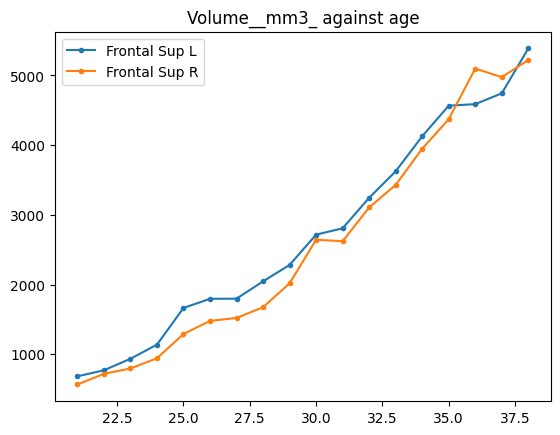

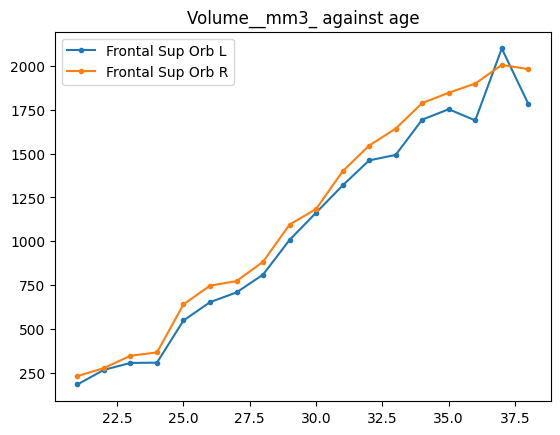

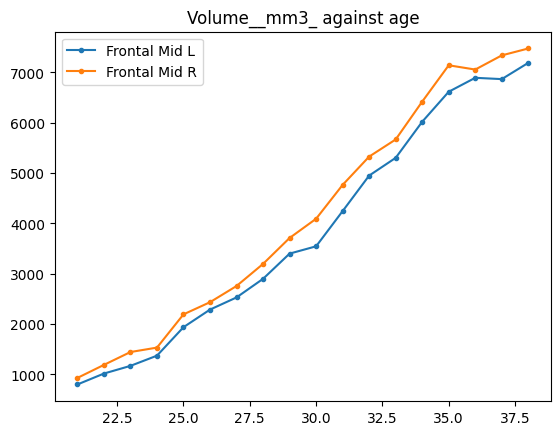

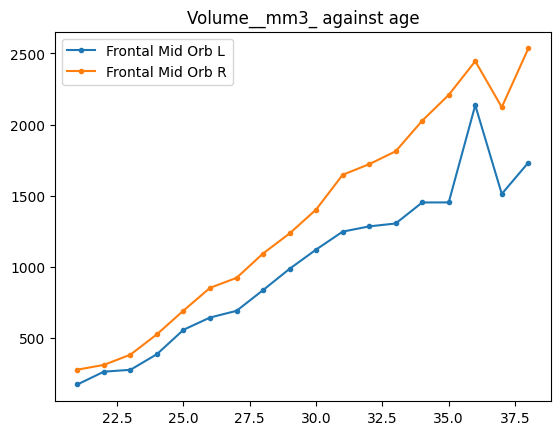

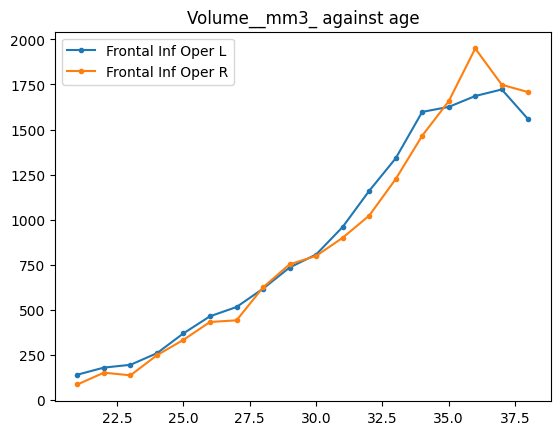

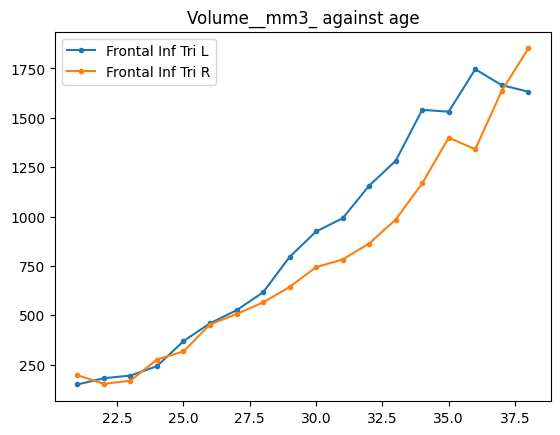

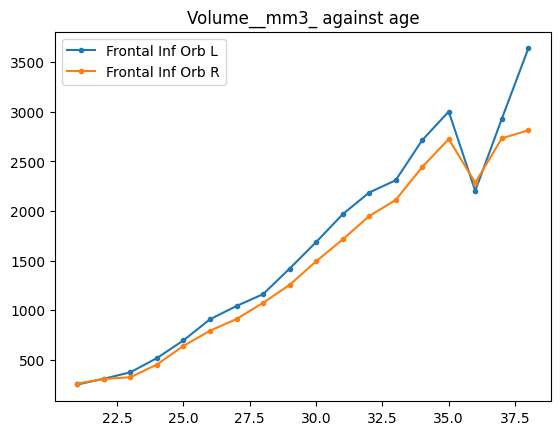

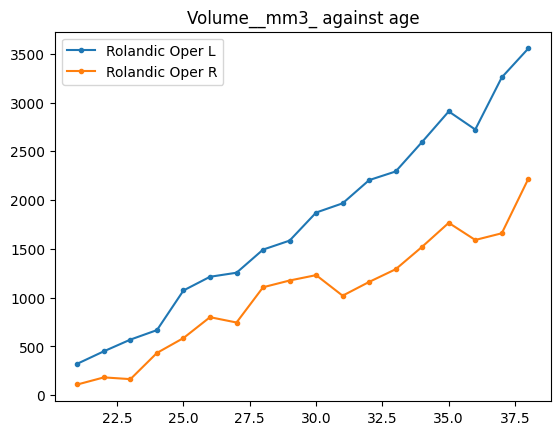

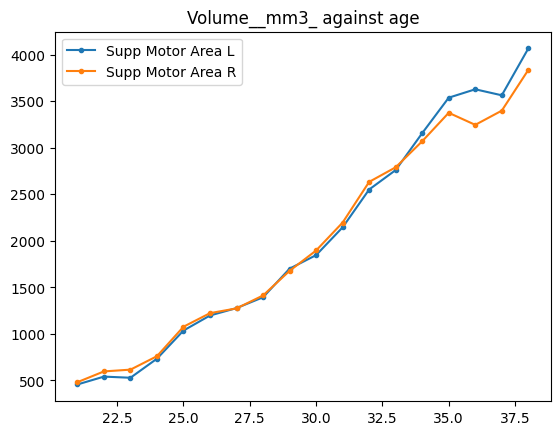

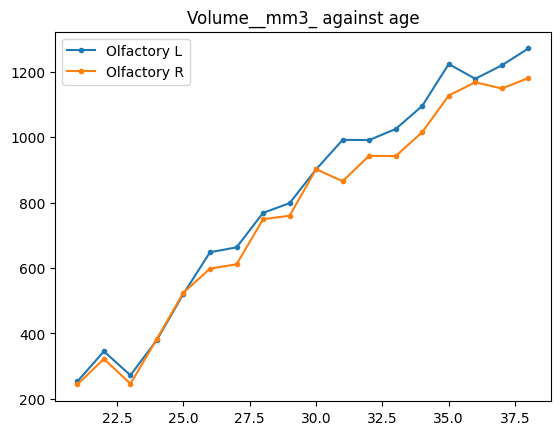

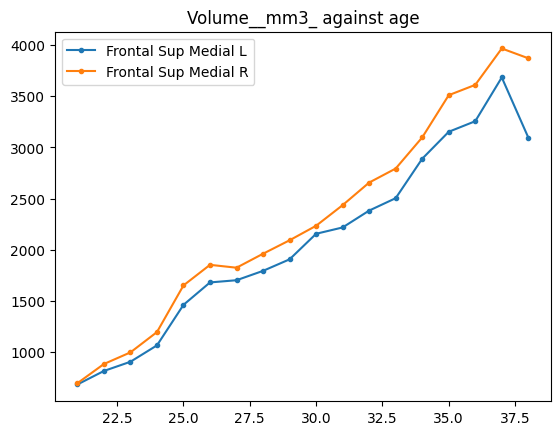

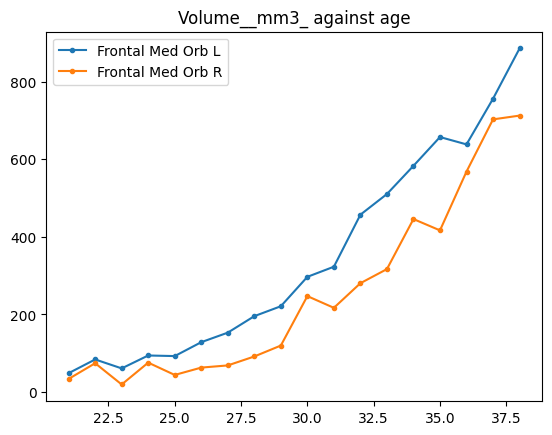

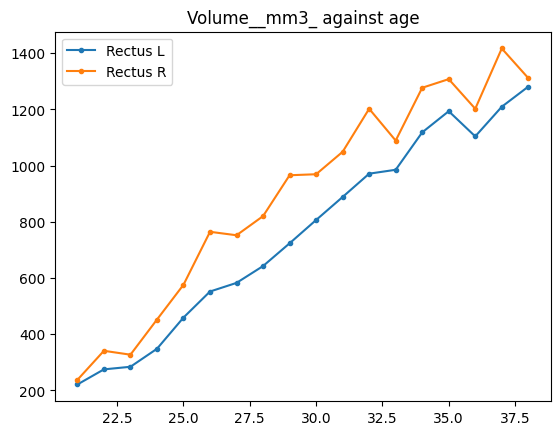

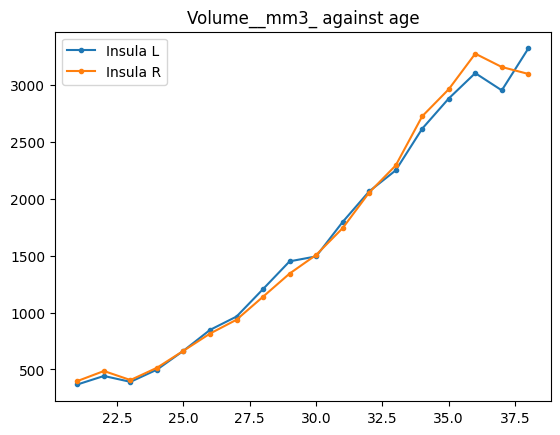

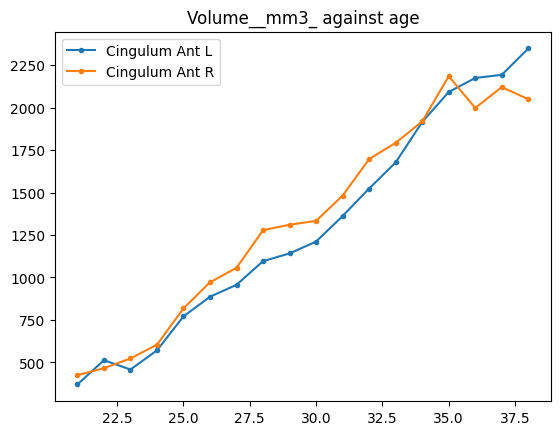

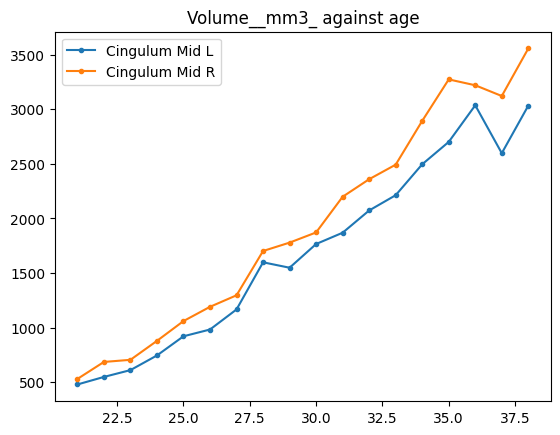

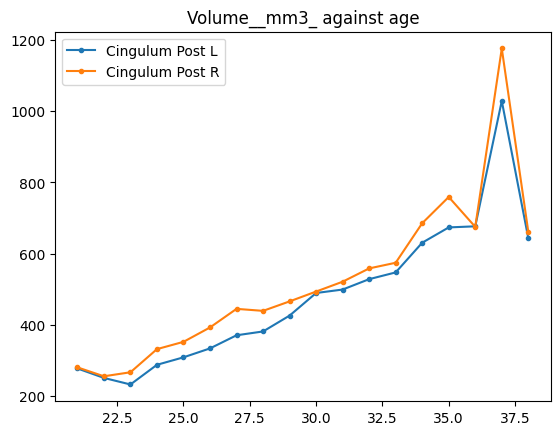

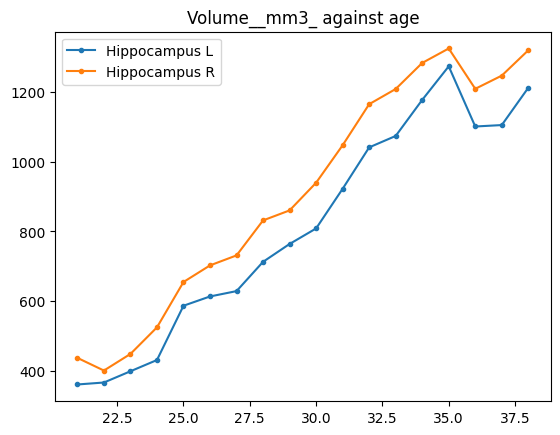

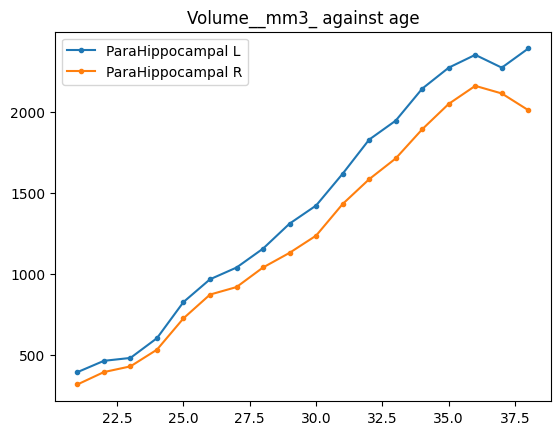

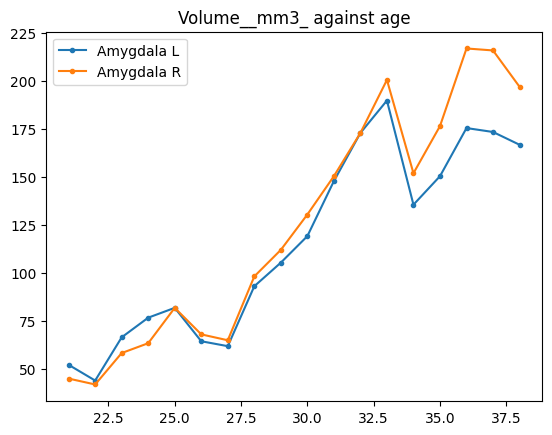

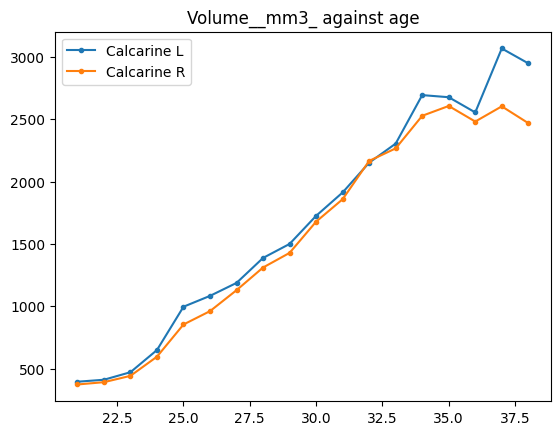

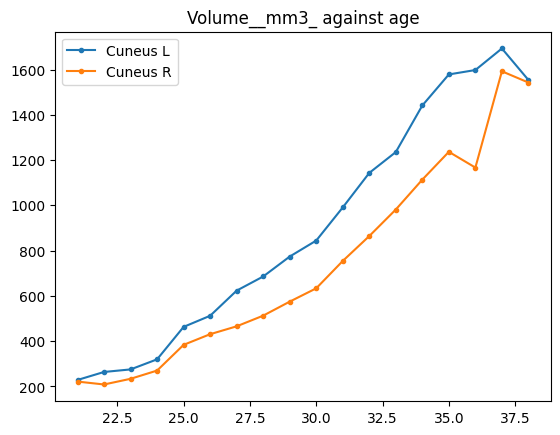

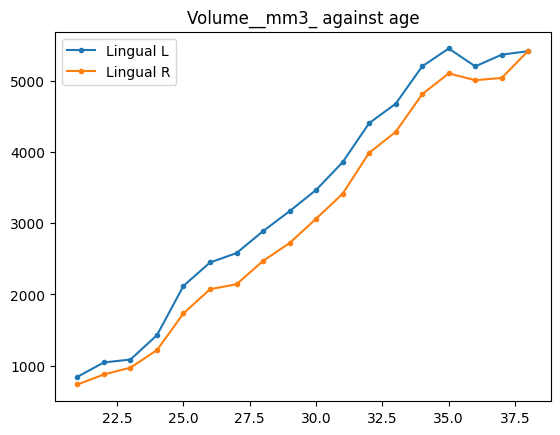

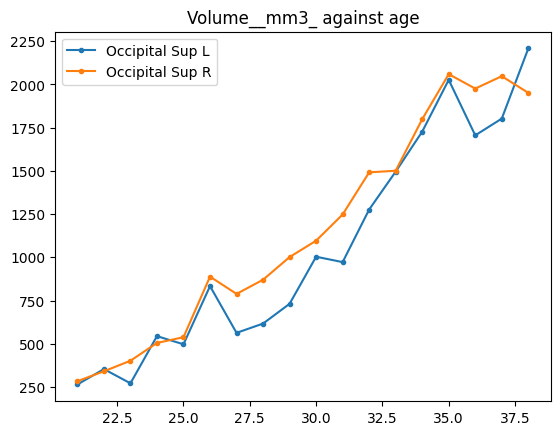

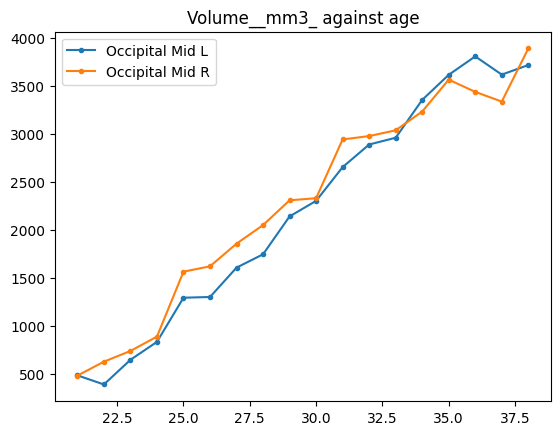

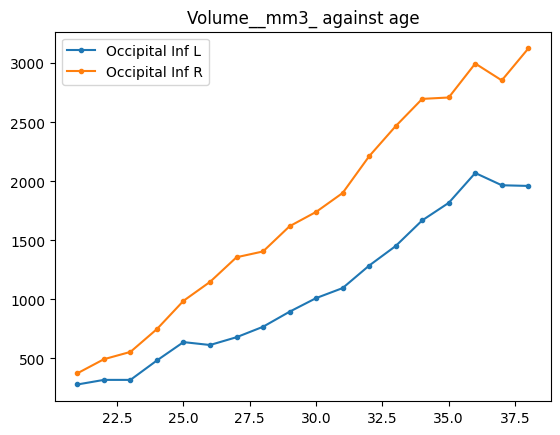

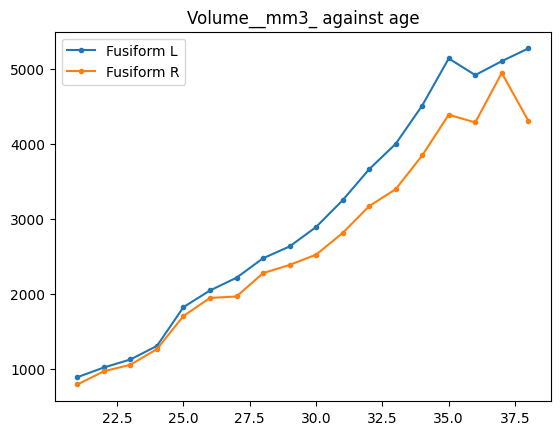

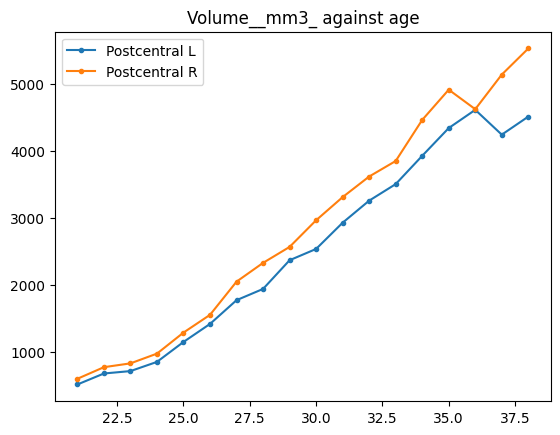

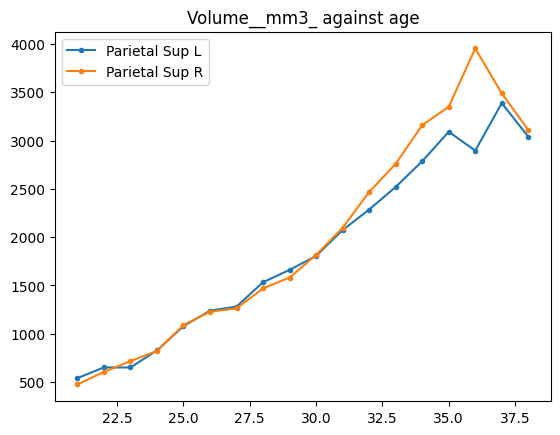

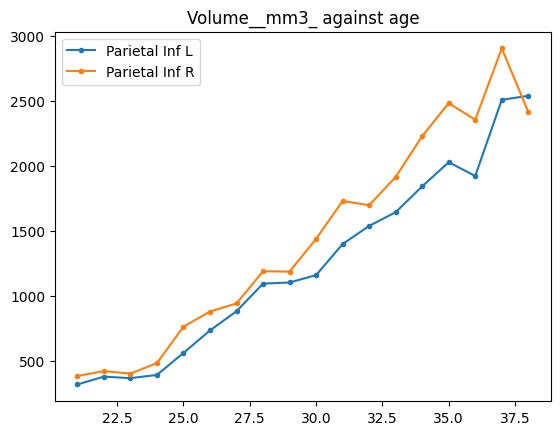

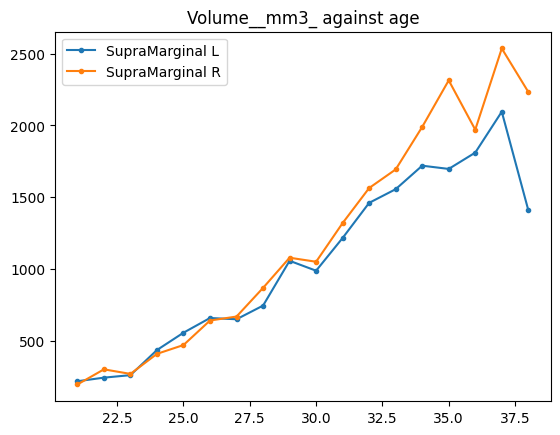

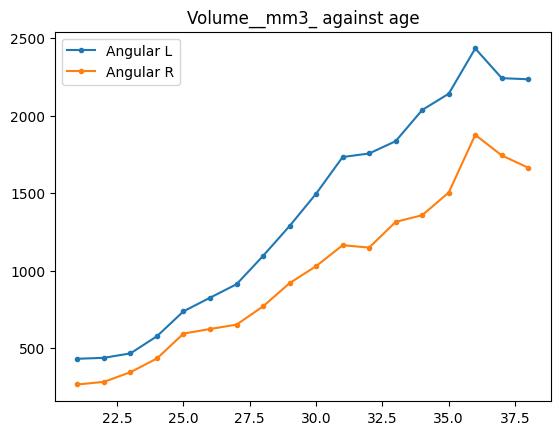

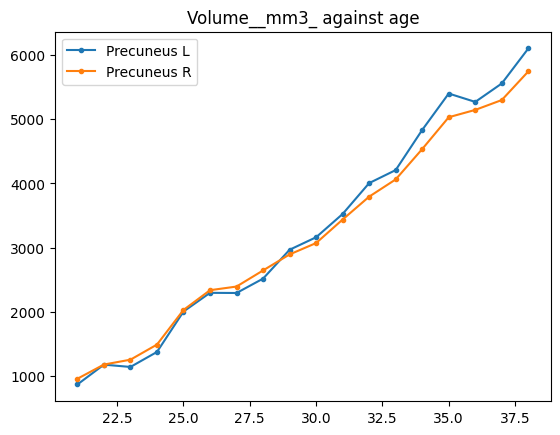

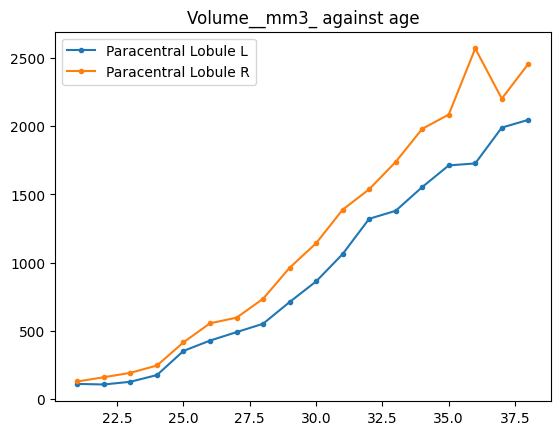

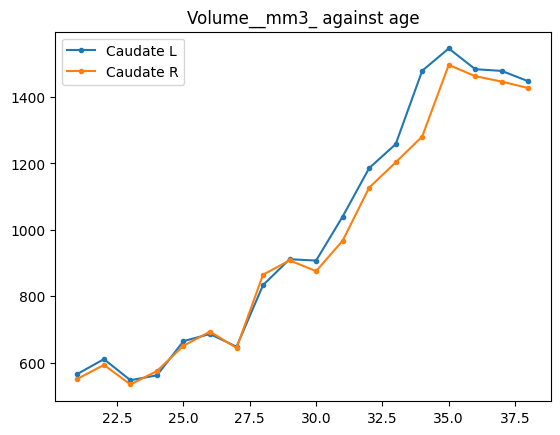

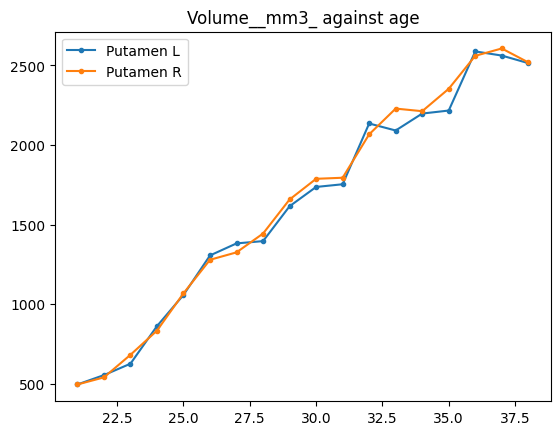

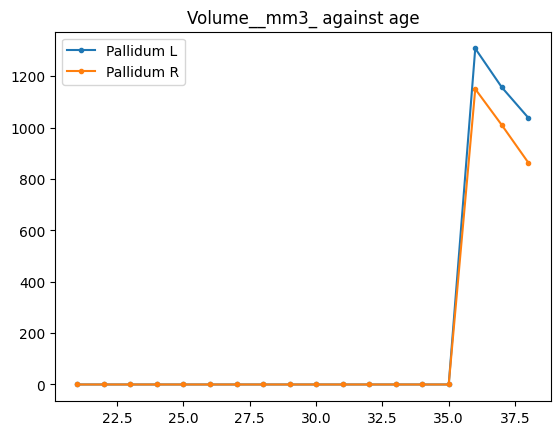

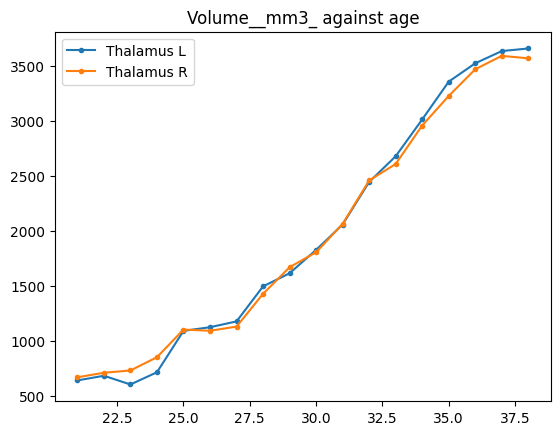

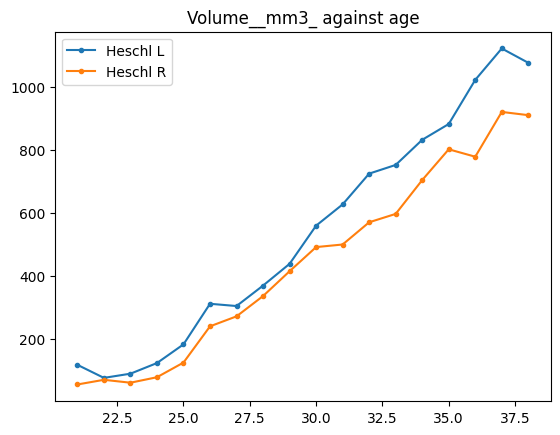

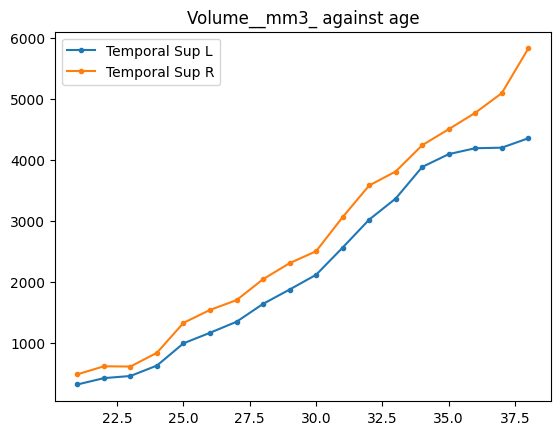

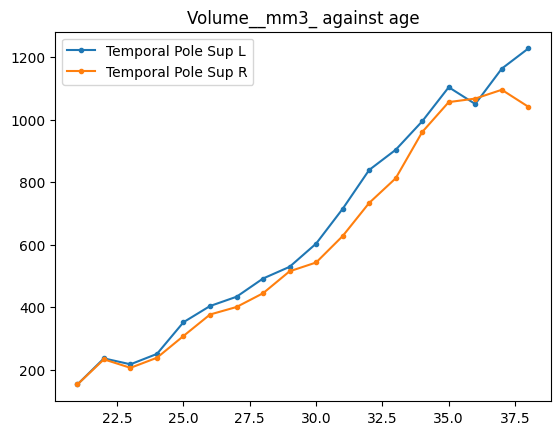

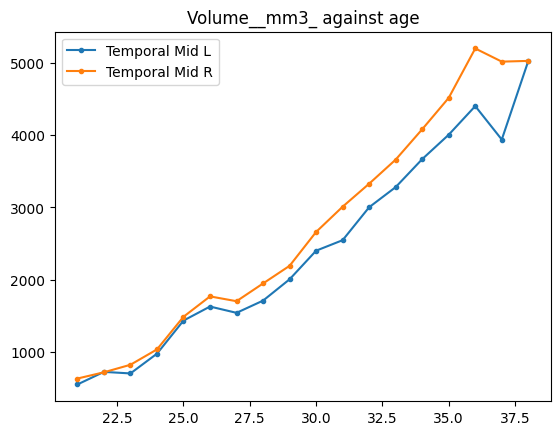

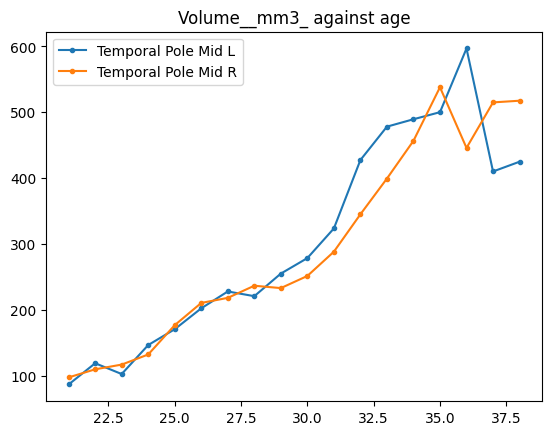

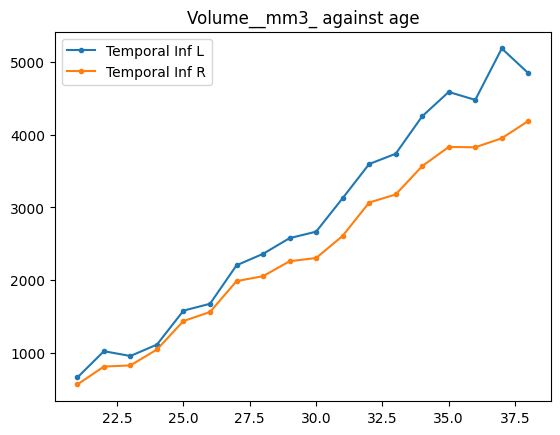

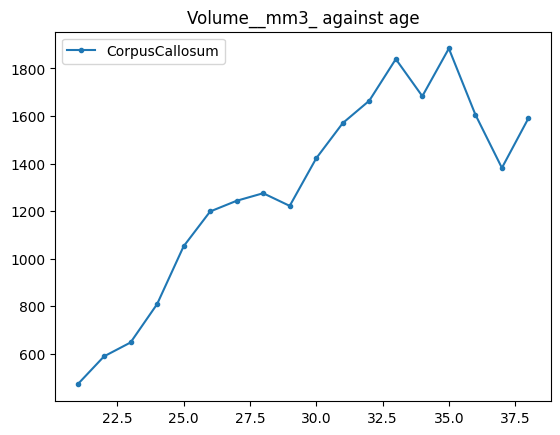

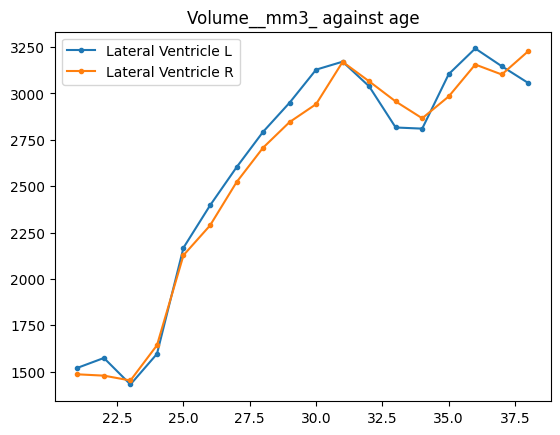

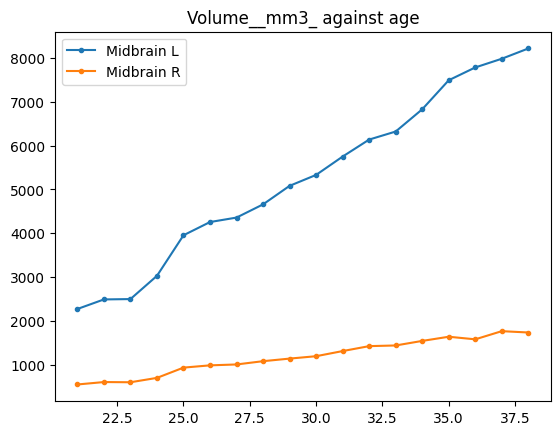

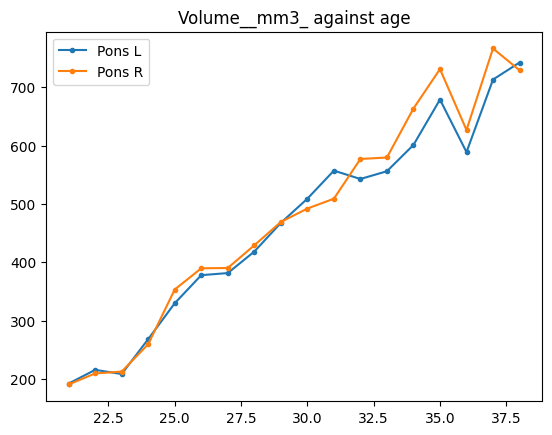

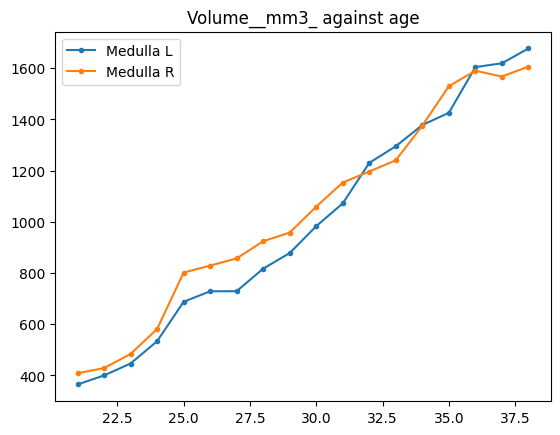

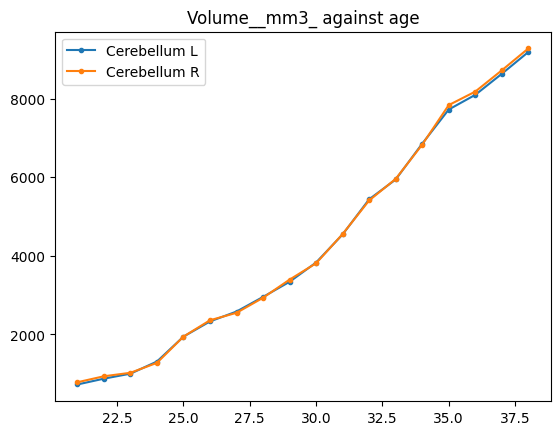

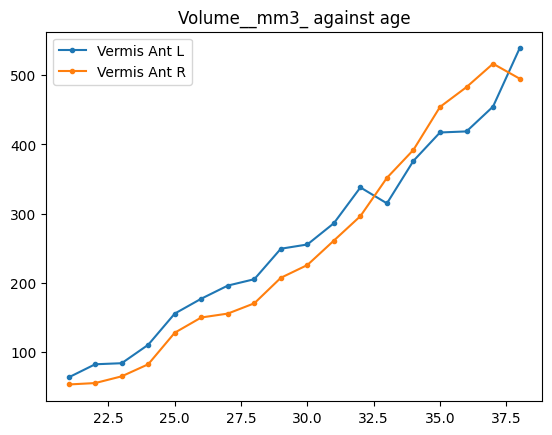

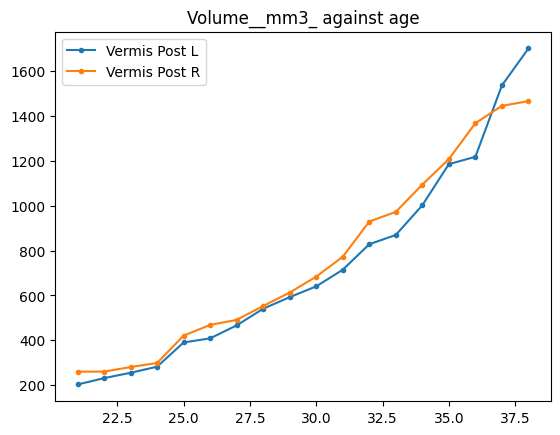

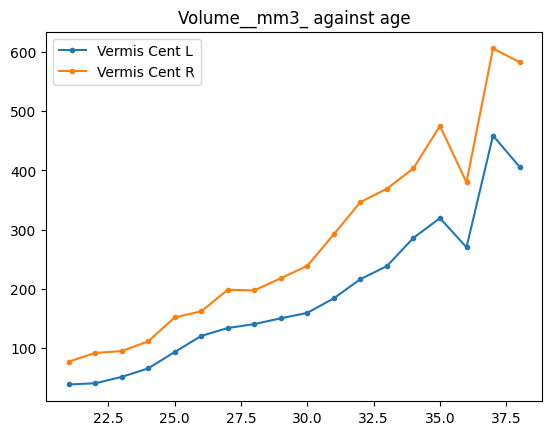

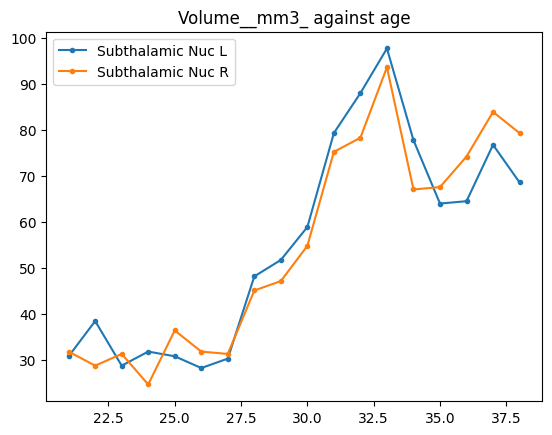

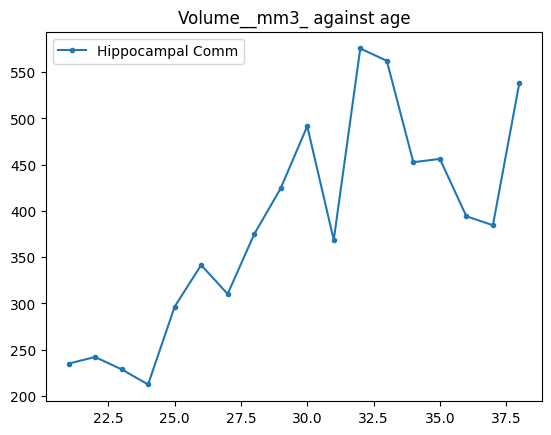

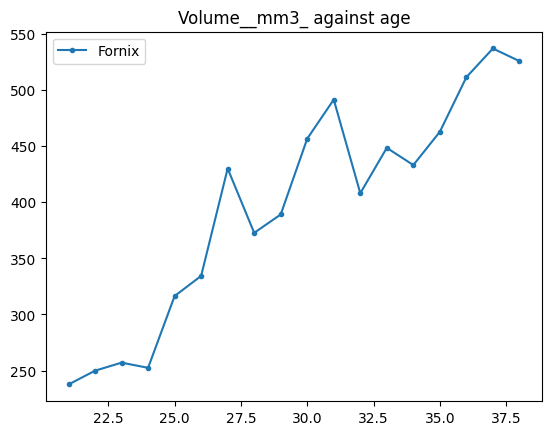

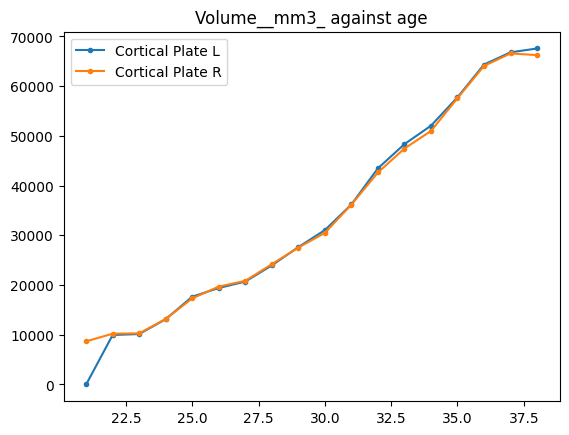

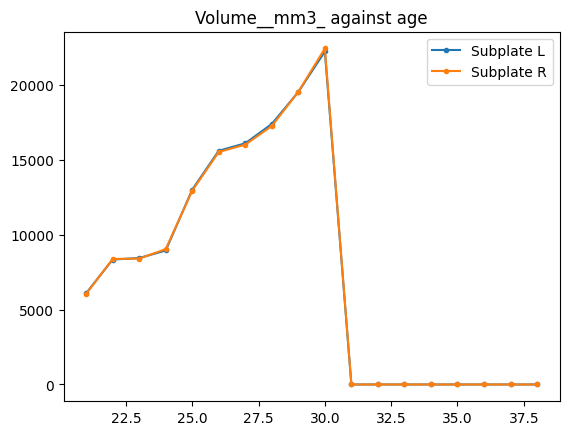

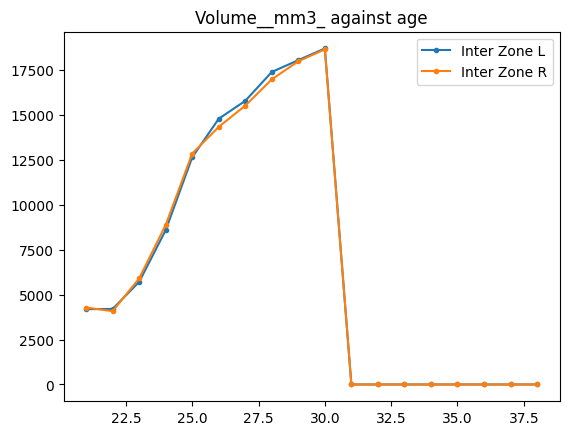

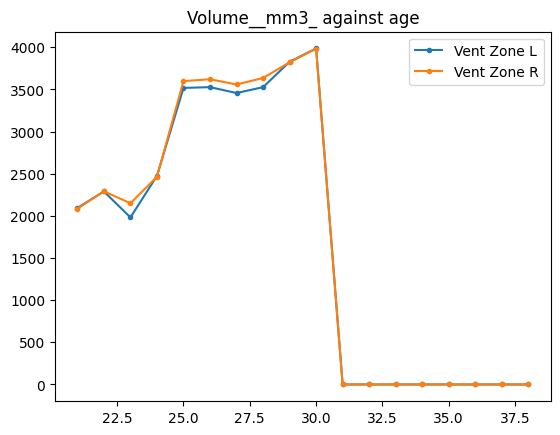

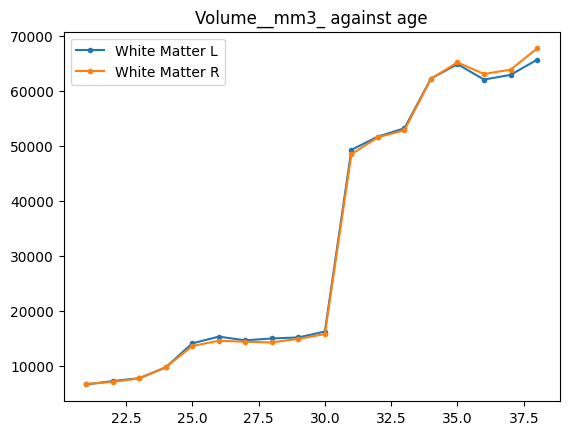

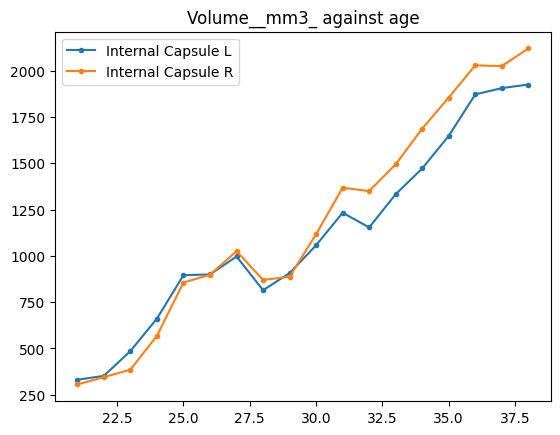

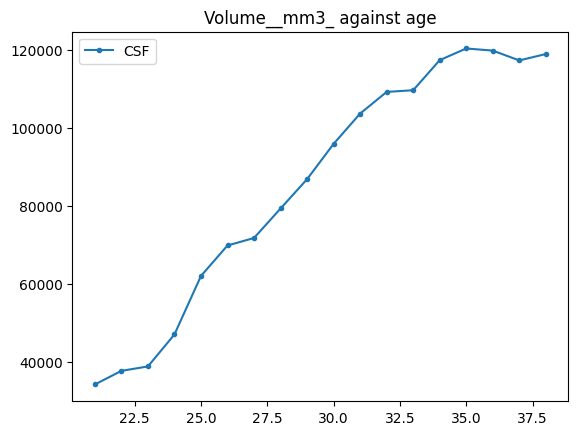

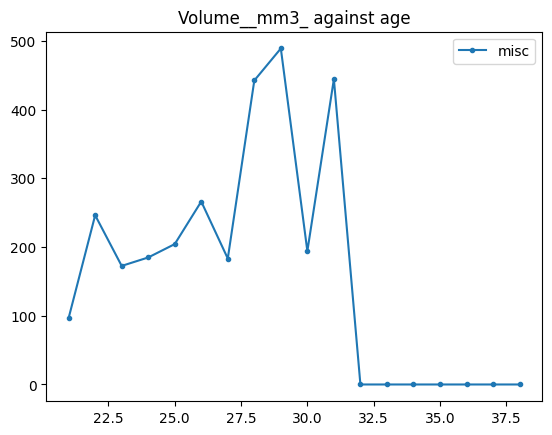

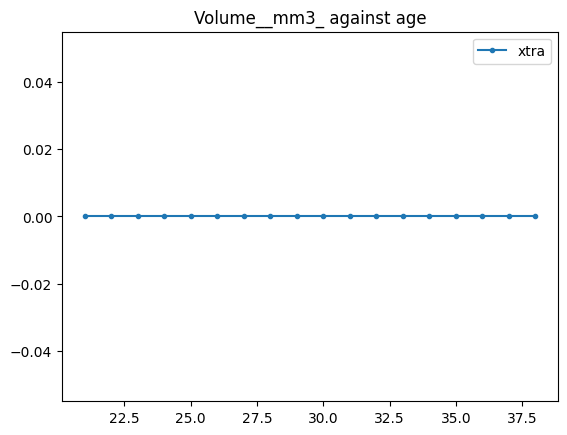

In [12]:
plotted = []
voldata = {}
for selected_region in regions:
    if selected_region not in plotted:
        bilateral = selected_region[-1]=='L' or selected_region[-1]=='R'
        if bilateral:
            selrgns = [selected_region[:-1]+'L', selected_region[:-1]+'R']
        else:
            selrgns = [selected_region]

        plotted.extend(selrgns)        

        plt.figure()
        for rgn in selrgns:
            voldata[rgn]=[]
            for age in ages:
                if rgn in agefiles[age][1]: # precedence to tissue segmentation
                    vol=float(getattr(agefiles[age][1][rgn],colname))
                elif rgn in agefiles[age][0]: # readable in region segmentation
                    vol=float(getattr(agefiles[age][0][rgn],colname))
                else:
                    vol = 0
                voldata[rgn].append(vol)
        for rgn in selrgns:
            plt.plot(ages,voldata[rgn],'.-')
        plt.legend(selrgns)
        plt.title(f'{colname} against age')

In [13]:
voldata

{'Clear Label': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
 'Precentral L': [620.03,
  752.125,
  872.445,
  940.54,
  1399.8,
  1603.58,
  1848.31,
  2082.3,
  2585.08,
  2989.56,
  3461.62,
  3984.37,
  4309.49,
  4879.34,
  5496.3,
  5371.88,
  5623.27,
  5600.75],
 'Precentral R': [616.958,
  727.037,
  747.517,
  968.7,
  1479.67,
  1636.86,
  1789.95,
  1946.1,
  2551.29,
  2943.99,
  3531.25,
  4012.02,
  4284.4,
  4804.59,
  5186.03,
  5128.68,
  5457.39,
  5511.66],
 'Frontal Sup L': [683.005,
  770.045,
  934.908,
  1137.66,
  1663.99,
  1795.07,
  1797.11,
  2045.43,
  2280.95,
  2715.64,
  2806.26,
  3244.02,
  3623.92,
  4126.7,
  4564.97,
  4587.5,
  4742.64,
  5385.71],
 'Frontal Sup R': [566.27,
  718.845,
  796.157,
  941.564,
  1290.24,
  1478.14,
  1520.63,
  1674.23,
  2016.76,
  2642.42,
  2620.92,
  3105.78,
  3429.36,
  3948.02,
  4371.44,
  5097.96,
  4974.06,
  5220.84],
 'Frontal Sup Orb L': [182.783,
  266.239,
  305.663,
  307.199,
  547.838,
  